# Getting started: finding and getting data from *NatureDataCube*

How to find datasets, define regions and dates of interest, search items and retrieve metadata with the wrapper functions `ndc_roi()`, `ndc_trange()`, `ndc_datasets()`, `ndc_count()` and `ndc_get()`. The raw STAC requests behind them are shown in [`advanced/stac_with_rstac`](advanced/stac_with_rstac.ipynb).

The example dates are fixed historical windows.

**Requires:** `NDC_TOKEN` environment variable

**Approximate runtime:** about 1 minute

**Author:** Bruno Marcos

**Created in:** June 5, 2026

In [1]:
# Load packages
pkgs <- c("rNDC", "dplyr")
suppressPackageStartupMessages(
  invisible(lapply(pkgs, FUN = library, character.only = TRUE))
)

# Define parameters
mytoken <- Sys.getenv("NDC_TOKEN")
startdate <- "2026-04-21"
enddate <- "2026-05-07"

# Define output directory
tmp <- tempdir()
print(tmp)

[1] "/tmp/RtmpaLXOl7"


## Importing and formatting custom regions of interest (RoI)

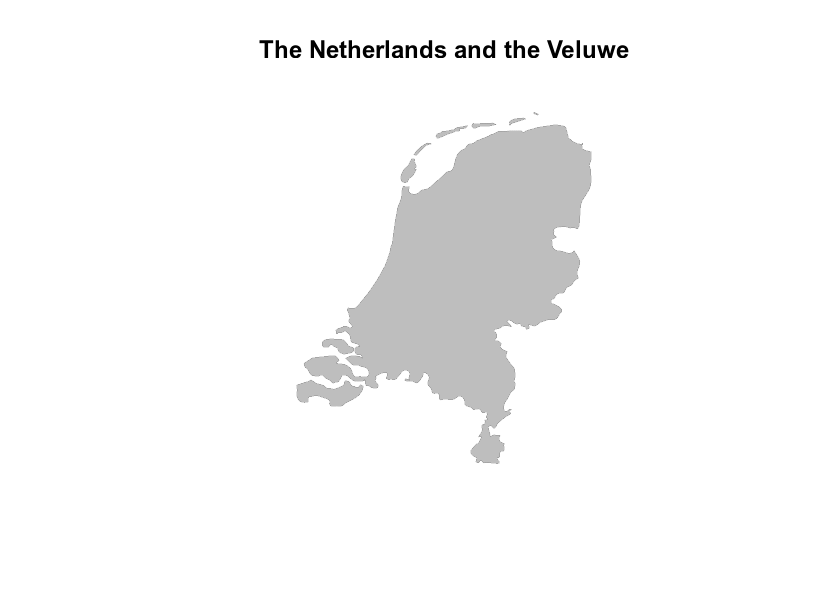

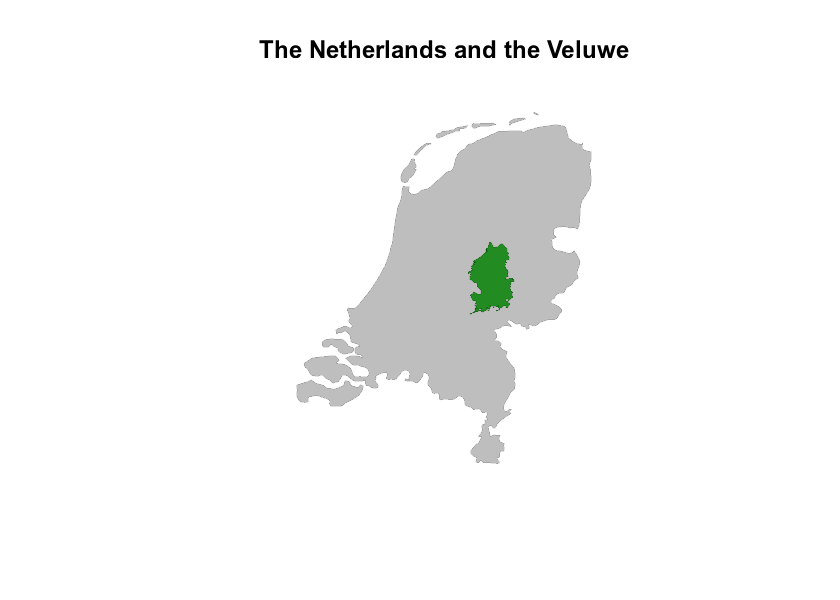

In [2]:
# Import boundaries 
nl <- system.file("extdata/nl.gpkg", package = "rNDC") |>
  ndc_roi()
veluwe <- system.file("extdata/veluwe.gpkg", package = "rNDC") |>
  ndc_roi()

# Visualize RoI
plot(nl, col = "grey", lwd = 0.1, main = "The Netherlands and the Veluwe")
plot(veluwe, col = "forestgreen", lwd = 0.1, add = TRUE)

## Formatting temporal ranges

### Single date

In [3]:
ndc_trange(startdate)

[1] "2026-04-21T00:00:00Z"


### Closed temporal ranges

In [4]:
twindow <- ndc_trange(c(startdate, enddate))
twindow

[1] "2026-04-21T00:00:00Z/2026-05-07T00:00:00Z"


### Closed temporal ranges (with automatic ordering)

In [5]:
ndc_trange(c(enddate, startdate))

[1] "2026-04-21T00:00:00Z/2026-05-07T00:00:00Z"


### Open temporal ranges

In [6]:
ndc_trange(c(startdate, NA))

[1] "2026-04-21T00:00:00Z/.."


In [7]:
ndc_trange(c(NA, enddate))

[1] "../2026-05-07T00:00:00Z"


## Listing available datasets

### List of dataset names (_Collection IDs_)

In [8]:
datasets <- ndc_datasets()
print(datasets)

 [1] "ndvi-lter"       "lter"            "snl"             "nh3"            
 [5] "nh3-snl"         "nox"             "nh3-lter"        "ntot"           
 [9] "lgn"             "lgn-lter"        "nox-snl"         "ntot-lter"      
[13] "ntot-snl"        "lgn-snl"         "nox-lter"        "soiltypes-lter" 
[17] "soiltypes-snl"   "ndvi"            "ndvi-snl"        "rgb"            
[21] "ahnmetrics-lter" "ahnmetrics-snl"  "soiltypes"       "ahnmetrics"     


### Total number of items for a single dataset

In [9]:
ndc_count(collection = "ndvi")

[1] 292


### Number of items of a single dataset matched with spatiotemporal contraints

In [10]:
ndc_count(collection = "ndvi",
          roi = veluwe,
          trange = twindow)

[1] 3


### Total number of items per dataset

In [11]:
ndc_datasets(total = TRUE)

        dataset_id  n_total
1        ndvi-lter     7489
2             lter       34
3              snl   264468
4              nh3        3
5          nh3-snl   792000
6              nox        3
7         nh3-lter      102
8             ntot        3
9              lgn        1
10        lgn-lter       34
11         nox-snl   792000
12       ntot-lter      102
13        ntot-snl   792541
14         lgn-snl   263994
15        nox-lter      102
16  soiltypes-lter       34
17   soiltypes-snl   264468
18            ndvi      292
19        ndvi-snl 35126884
20             rgb      291
21 ahnmetrics-lter       68
22  ahnmetrics-snl   455219
23       soiltypes        1
24      ahnmetrics        2


### Number of matched items per dataset (spatial contraints only)

In [12]:
ndc_datasets(roi = veluwe)

        dataset_id n_matched
1        ndvi-lter      6254
2             lter        28
3              snl     13955
4              nh3         3
5          nh3-snl     41859
6              nox         3
7         nh3-lter        84
8             ntot         3
9              lgn         1
10        lgn-lter        28
11         nox-snl     41859
12       ntot-lter        84
13        ntot-snl     41859
14         lgn-snl     13953
15        nox-lter        84
16  soiltypes-lter        28
17   soiltypes-snl     13953
18            ndvi       292
19        ndvi-snl   3248027
20             rgb       291
21 ahnmetrics-lter        56
22  ahnmetrics-snl     27048
23       soiltypes         1
24      ahnmetrics         2


### Complete table of available datasets for specific spatiotemporal constraints

In [13]:
ndc_datasets(roi = veluwe,
             trange = twindow,
             total = TRUE)

        dataset_id  n_total n_matched
1        ndvi-lter     7489       159
2             lter       34        28
3              snl   264468     13955
4              nh3        3         0
5          nh3-snl   792000         0
6              nox        3         0
7         nh3-lter      102         0
8             ntot        3         0
9              lgn        1         0
10        lgn-lter       34         0
11         nox-snl   792000         0
12       ntot-lter      102         0
13        ntot-snl   792541         0
14         lgn-snl   263994         0
15        nox-lter      102         0
16  soiltypes-lter       34         0
17   soiltypes-snl   264468         0
18            ndvi      292         3
19        ndvi-snl 35126884     67926
20             rgb      291         3
21 ahnmetrics-lter       68         0
22  ahnmetrics-snl   455219         0
23       soiltypes        1         0
24      ahnmetrics        2         0


## Searching & listing items

### Search all items within a dataset

In [14]:
ndc_get(collection = "ndvi")

###Items
- matched feature(s): 292
- features (100 item(s) / 192 not fetched):
  - gm-groenmonitor__ndvi_20260814
  - gm-groenmonitor__ndvi_20260812
  - gm-groenmonitor__ndvi_20260809
  - gm-groenmonitor__ndvi_20260804
  - gm-groenmonitor__ndvi_20260728
  - gm-groenmonitor__ndvi_20260725
  - gm-groenmonitor__ndvi_20260713
  - gm-groenmonitor__ndvi_20260625
  - gm-groenmonitor__ndvi_20260620
  - gm-groenmonitor__ndvi_20260528
  - ... with 90 more feature(s).
- assets: download, legend, thumbnail, wcs, wms
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type


### Search items of a dataset that match spatiotemporal constraints

In [15]:
myquery <- ndc_get(collection = "ndvi",
                   roi = veluwe,
                   trange = twindow)
print(myquery)

###Items
- matched feature(s): 3
- features (3 item(s) / 0 not fetched):
  - gm-groenmonitor__ndvi_20260501
  - gm-groenmonitor__ndvi_20260429
  - gm-groenmonitor__ndvi_20260421
- assets: download, legend, thumbnail, wcs, wms
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type


### Counting number of matched items using search results

In [16]:
ndc_count(myquery)

[1] 3


## Retrieving metadata

### Retrieving NDVI stats for LTER sites

In [17]:
ndvi <- ndc_get(collection = "ndvi-lter",
                roi = veluwe,
                mode = "sf",
                limit = 10000)
print(ndvi)

# `ndc_get()` only converts the first page of results: check that nothing is missing
# (a warning is raised otherwise; increase `limit` or use `mode = "fetch"`)
stopifnot(nrow(ndvi) == ndc_count(collection = "ndvi-lter", roi = veluwe))

Simple feature collection with 6254 features and 9 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.936116 ymax: 52.37747
Geodetic CRS:  WGS 84
# A tibble: 6,254 × 10
   datetime             ndc_id  ndvi_count ndvi_mean ndvi_std observation_date  
   <chr>                <chr>        <dbl>     <dbl>    <dbl> <chr>             
 1 2026-05-28T00:00:00Z 1264498         31     0.726   0.102  2026-05-28T00:00:…
 2 2026-05-28T00:00:00Z 1264497         34     0.741   0.0945 2026-05-28T00:00:…
 3 2026-05-28T00:00:00Z 1264496         29     0.689   0.100  2026-05-28T00:00:…
 4 2026-05-28T00:00:00Z 1264495         32     0.752   0.0503 2026-05-28T00:00:…
 5 2026-05-28T00:00:00Z 1264491         30     0.702   0.110  2026-05-28T00:00:…
 6 2026-05-28T00:00:00Z 1264490         21     0.819   0.0428 2026-05-28T00:00:…
 7 2026-05-28T00:00:00Z 1264489         20     0.756   0.0896 2026-05-28T00:00:…
 8 2026-05-28T00:00:00Z 1264488         33     

### Temporally aggregating NDVI mean by patch ID

_Note:_ The "ndvi_mean" and "ndvi_std" fields obtained through the "ndvi-lter" Collection metadata contain **spatially** aggregated values (i.e. from multiple pixels).

The following aggregates NDVI (spatial) mean values to only one value for each polygon.

In [18]:
ndvi |>
  summarize(NDVI_mean = mean(ndvi_mean, na.rm = TRUE),
            NDVI_sd = sd(ndvi_mean, na.rm = TRUE),
            NDVI_min = min(ndvi_mean, na.rm = TRUE),
            NDVI_max = max(ndvi_mean, na.rm = TRUE),
            across(geometry, st_union), # Only needed if `ndvi` is an `sf` object
            .by = ndc_id)

Simple feature collection with 28 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.936116 ymax: 52.37747
Geodetic CRS:  WGS 84
# A tibble: 28 × 6
   ndc_id  NDVI_mean NDVI_sd NDVI_min NDVI_max                          geometry
   <chr>       <dbl>   <dbl>    <dbl>    <dbl>                     <POLYGON [°]>
 1 1264498     0.693  0.0544    0.538    0.820 ((5.897389 52.37651, 5.897503 52…
 2 1264497     0.700  0.0569    0.533    0.819 ((5.895003 52.3746, 5.895116 52.…
 3 1264496     0.693  0.0672    0.466    0.819 ((5.891448 52.37194, 5.891562 52…
 4 1264495     0.705  0.0621    0.534    0.832 ((5.888749 52.36961, 5.888863 52…
 5 1264491     0.693  0.0627    0.442    0.836 ((5.886106 52.36824, 5.886218 52…
 6 1264490     0.736  0.0781    0.560    0.871 ((5.852229 52.36794, 5.852343 52…
 7 1264489     0.734  0.0650    0.579    0.864 ((5.853585 52.36701, 5.853698 52…
 8 1264488     0.681  0.0675    0.409    0.820 ((5.885192 

The following aggregates NDVI (spatial) mean values to one value **per year**, for each polygon.

In [19]:
ndvi |>
  mutate(year = substr(observation_date, 1,4)) |>
  summarize(NDVI_mean = mean(ndvi_mean, na.rm = TRUE),
            NDVI_sd = sd(ndvi_mean, na.rm = TRUE),
            NDVI_min = min(ndvi_mean, na.rm = TRUE),
            NDVI_max = max(ndvi_mean, na.rm = TRUE),
            across(geometry, st_union), # Only needed if `ndvi` is an `sf` object
            .by = c(ndc_id, year))

Simple feature collection with 224 features and 6 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.936116 ymax: 52.37747
Geodetic CRS:  WGS 84
# A tibble: 224 × 7
   ndc_id  year  NDVI_mean NDVI_sd NDVI_min NDVI_max                    geometry
   <chr>   <chr>     <dbl>   <dbl>    <dbl>    <dbl>               <POLYGON [°]>
 1 1264498 2026      0.691  0.0429    0.599    0.809 ((5.897389 52.37651, 5.897…
 2 1264497 2026      0.696  0.0322    0.610    0.741 ((5.895003 52.3746, 5.8951…
 3 1264496 2026      0.624  0.0539    0.466    0.697 ((5.891448 52.37194, 5.891…
 4 1264495 2026      0.702  0.0375    0.606    0.765 ((5.888749 52.36961, 5.888…
 5 1264491 2026      0.651  0.0319    0.573    0.712 ((5.886106 52.36824, 5.886…
 6 1264490 2026      0.693  0.0615    0.590    0.819 ((5.852229 52.36794, 5.852…
 7 1264489 2026      0.699  0.0437    0.609    0.761 ((5.853585 52.36701, 5.853…
 8 1264488 2026      0.622  0.0336    0.548    0.690 ((5